In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [135]:
cal = pd.read_csv('data\calories.csv')
ers = pd.read_csv('data\exercise.csv')

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\namde\AppData\Local\Temp\ipykernel_11928\1983537053.py:1: SyntaxWarning: invalid escape sequence '\c'
  cal = pd.read_csv('data\calories.csv')
C:\Users\namde\AppData\Local\Temp\ipykernel_11928\1983537053.py:2: SyntaxWarning: invalid escape sequence '\e'
  ers = pd.read_csv('data\exercise.csv')


In [136]:
cal.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [137]:
ers.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [138]:
print(cal.shape)
print(ers.shape)

(15000, 2)
(15000, 8)


In [139]:
ers.describe().round(1)

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,15000.0,15000.0,15000.0,15000.0,15000.0,15000.0,15000.0
mean,14977358.5,42.8,174.5,75.0,15.5,95.5,40.0
std,2872851.5,17.0,14.3,15.0,8.3,9.6,0.8
min,10001159.0,20.0,123.0,36.0,1.0,67.0,37.1
25%,12474190.8,28.0,164.0,63.0,8.0,88.0,39.6
50%,14997285.0,39.0,175.0,74.0,16.0,96.0,40.2
75%,17449278.8,56.0,185.0,87.0,23.0,103.0,40.6
max,19999647.0,79.0,222.0,132.0,30.0,128.0,41.5


In [140]:
df = ers.merge(cal)
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


# **EDA**

## Univariate Analysis

Text(0, 0.5, 'Count')

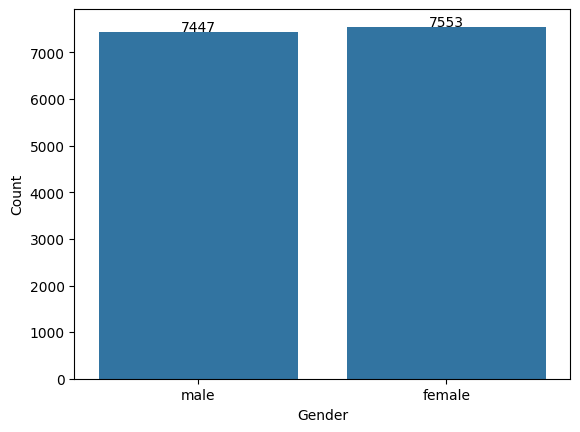

In [141]:
ax = sns.countplot(x='Gender', data=df)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 10, int(height), ha='center')

ax.set_ylabel('Count')

<Axes: xlabel='Age', ylabel='Count'>

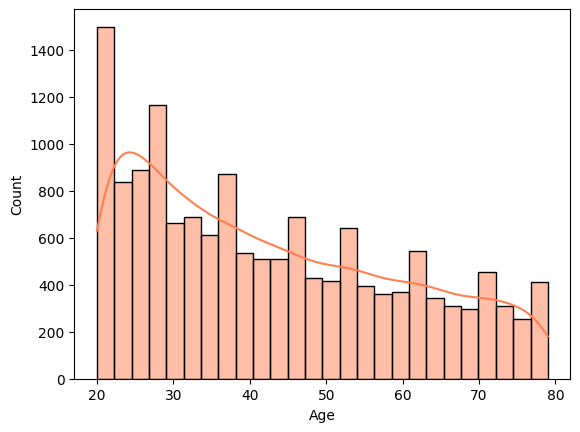

In [142]:
sns.histplot(df['Age'] ,kde=True, color='coral')

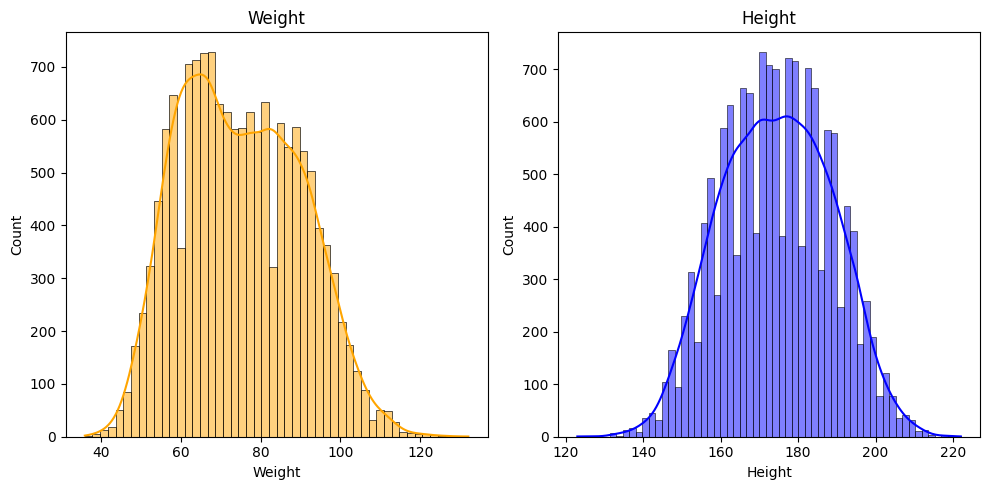

In [143]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['Weight'], kde=True, color='orange')
plt.title("Weight")

plt.subplot(1,2,2)
sns.histplot(df['Height'], kde=True, color='blue')
plt.title("Height")

plt.tight_layout()
plt.show()

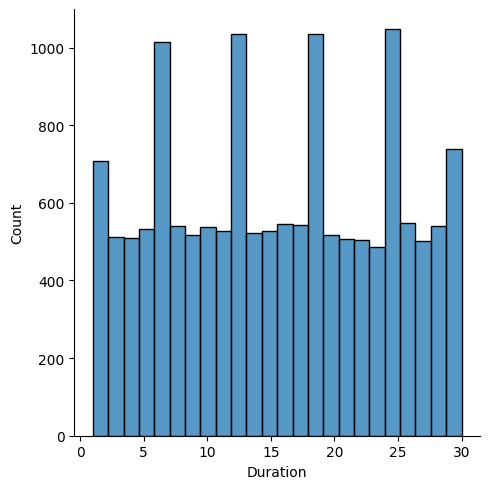

In [144]:
sns.displot(df['Duration'])

<Axes: xlabel='Calories', ylabel='Count'>

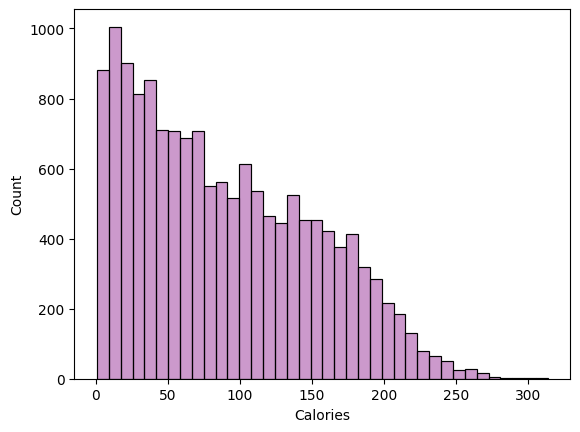

In [145]:
sns.histplot(df['Calories'], color='purple', alpha=0.4)

## Bivariate Analysis

<Axes: xlabel='Age', ylabel='Height'>

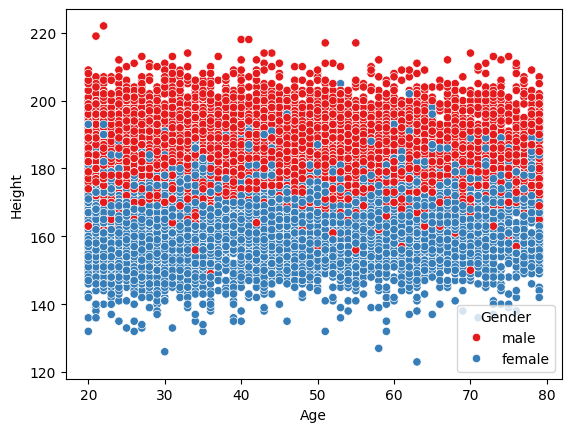

In [146]:
sns.scatterplot(y='Height', x='Age', data=df, hue='Gender', palette='Set1')

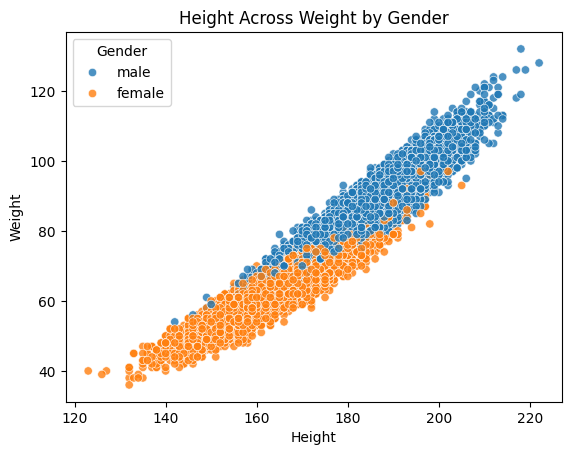

In [147]:
sns.scatterplot(y='Weight', x='Height', data=df, color='green', alpha=0.8, hue='Gender')
plt.title("Height Across Weight by Gender")
plt.show()

In [148]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


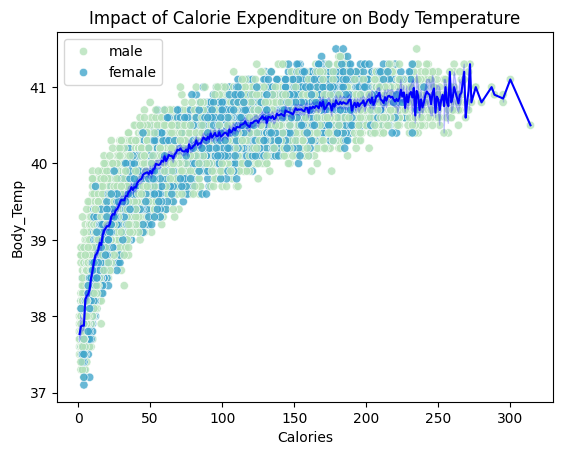

In [162]:
sns.scatterplot(y='Body_Temp', x='Calories', data=df, color='green', alpha=0.8, hue='Gender', palette='GnBu')
sns.lineplot(y='Body_Temp', x='Calories', data=df, color='blue')
plt.title("Impact of Calorie Expenditure on Body Temperature")
plt.show()

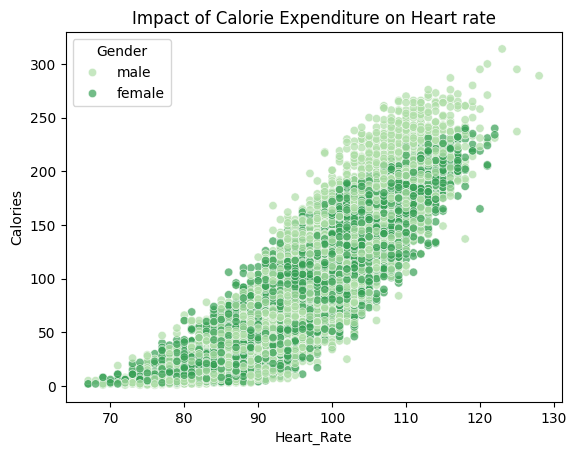

In [166]:
sns.scatterplot(y='Calories', x='Heart_Rate', data=df, alpha=0.7, color='green', hue='Gender', palette='Greens')
plt.title("Impact of Calorie Expenditure on Heart rate")
plt.show()

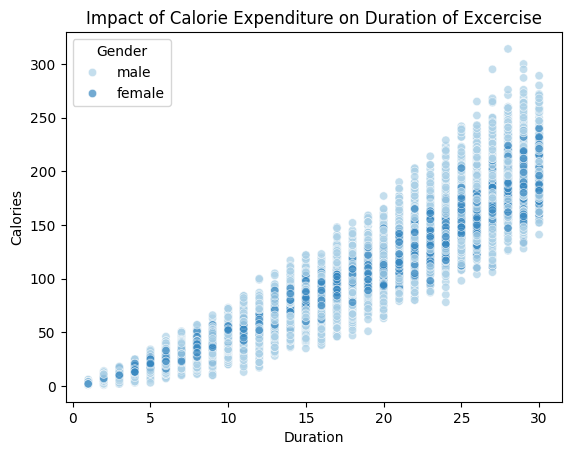

In [152]:
sns.scatterplot(y='Calories', x='Duration', data=df, alpha=0.7, color='green', hue='Gender', palette='Blues')
plt.title("Impact of Calorie Expenditure on Duration of Excercise")
plt.show()

<Axes: xlabel='Duration', ylabel='Heart_Rate'>

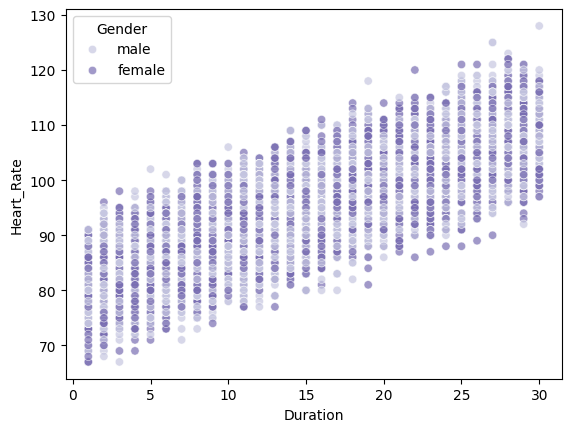

In [167]:
sns.scatterplot(y='Heart_Rate', x='Duration', data=df, alpha=0.7, color='green', hue='Gender', palette='Purples')

<Axes: xlabel='Body_Temp', ylabel='Heart_Rate'>

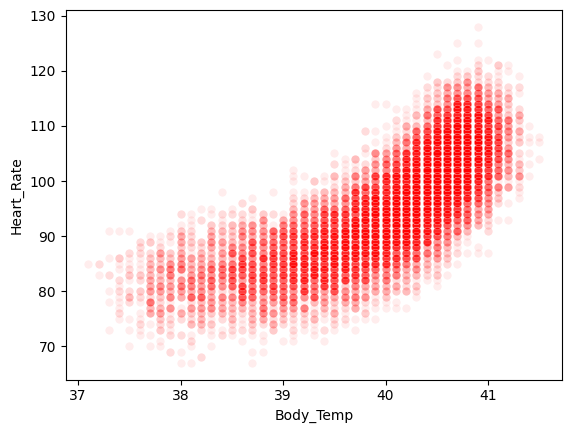

In [179]:
sns.scatterplot(y='Heart_Rate', x='Body_Temp', data=df, alpha=0.07, color='Red')

<Axes: xlabel='Age', ylabel='Calories'>

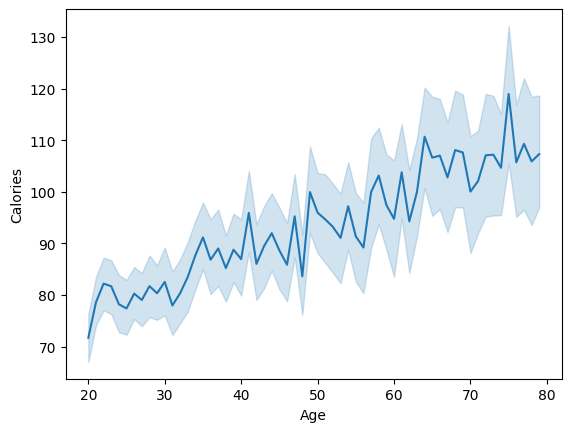

In [182]:
sns.lineplot(x = df['Age'],y = df['Calories'])

<Axes: >

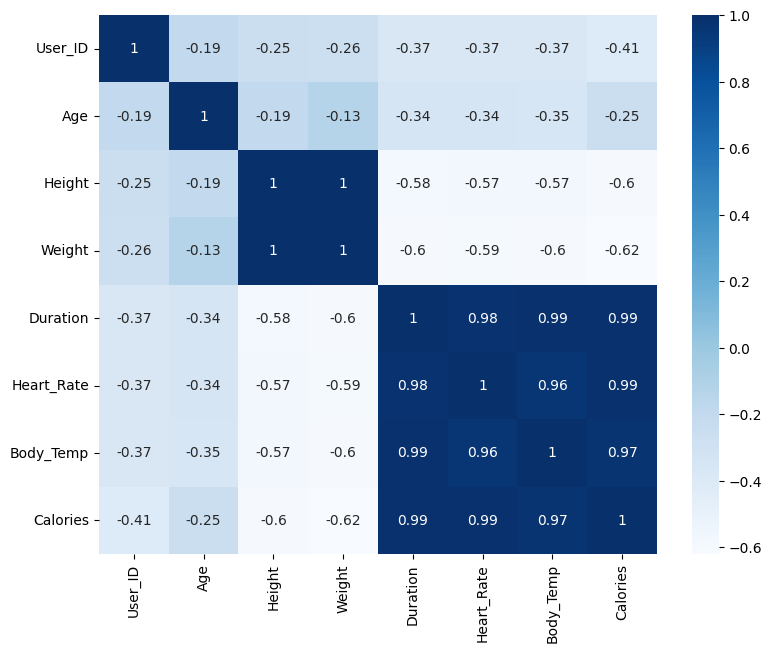

In [196]:
corr = df.corr(numeric_only=True).corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr.round(2),annot=True, cmap='Blues')

In [ ]:
'''
palettes = [
    "deep", "muted", "bright", "pastel", "dark", "colorblind",  # Default categorical
    "Set1", "Set2", "Set3", "Paired", "Accent", "tab10",         # ColorBrewer categorical
    "Blues", "BuGn", "BuPu", "GnBu", "Greens", "Greys", "Oranges", "OrRd", "PuBu", "PuBuGn", "PuRd", "Purples", "RdPu", "Reds", "YlGn", "YlGnBu", "YlOrBr", "YlOrRd",  # Sequential
    "BrBG", "PiYG", "PRGn", "PuOr", "RdBu", "RdGy", "RdYlBu", "RdYlGn", "Spectral"  # Diverging
]
'''

'\npalettes = [\n    "deep", "muted", "bright", "pastel", "dark", "colorblind",  # Default categorical\n    "Set1", "Set2", "Set3", "Paired", "Accent", "tab10",         # ColorBrewer categorical\n    "Blues", "BuGn", "BuPu", "GnBu", "Greens", "Greys", "Oranges", "OrRd", "PuBu", "PuBuGn", "PuRd", "Purples", "RdPu", "Reds", "YlGn", "YlGnBu", "YlOrBr", "YlOrRd",  # Sequential\n    "BrBG", "PiYG", "PRGn", "PuOr", "RdBu", "RdGy", "RdYlBu", "RdYlGn", "Spectral"  # Diverging\n]\n'

In [198]:
df['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

In [202]:
df['Gender'] = df['Gender'].map({'male':0, 'female':1})

In [204]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  int64  
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 1.0 MB


In [203]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
